## 1. Import Libraries

We'll use scikit-learn for machine learning, pandas for data manipulation, and matplotlib/seaborn for visualization.

In [3]:
# Core libraries
# Visualization
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Machine Learning
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set style for plots
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

# Suppress warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

The Diabetes dataset is a classic regression dataset included with scikit-learn. It contains 10 baseline variables (age, sex, BMI, blood pressure, and six blood serum measurements) for 442 diabetes patients. The target is a quantitative measure of disease progression one year after baseline.

In [4]:
# Load the Diabetes dataset (no download required - bundled with sklearn)
diabetes = load_diabetes(as_frame=True)

# Create DataFrame
df = diabetes.frame

# Display basic info
print(f"Dataset Shape: {df.shape}")
print(f"Number of samples: {df.shape[0]:,}")
print(f"Number of features: {df.shape[1] - 1}")
print("\nTarget variable: target (Disease progression measure)")
print("\n" + "=" * 60)
print("\nFeature Descriptions:")
print("-" * 60)

feature_descriptions = {
    "age": "Age of the patient",
    "sex": "Sex of the patient",
    "bmi": "Body mass index",
    "bp": "Average blood pressure",
    "s1": "TC - Total serum cholesterol",
    "s2": "LDL - Low-density lipoproteins",
    "s3": "HDL - High-density lipoproteins",
    "s4": "TCH - Total cholesterol / HDL",
    "s5": "LTG - Log of serum triglycerides",
    "s6": "GLU - Blood sugar level",
}

for feature, desc in feature_descriptions.items():
    print(f"  {feature:6} - {desc}")

Dataset Shape: (442, 11)
Number of samples: 442
Number of features: 10

Target variable: target (Disease progression measure)


Feature Descriptions:
------------------------------------------------------------
  age    - Age of the patient
  sex    - Sex of the patient
  bmi    - Body mass index
  bp     - Average blood pressure
  s1     - TC - Total serum cholesterol
  s2     - LDL - Low-density lipoproteins
  s3     - HDL - High-density lipoproteins
  s4     - TCH - Total cholesterol / HDL
  s5     - LTG - Log of serum triglycerides
  s6     - GLU - Blood sugar level


In [5]:
# Display first few rows
print("First 5 rows of the dataset:")
df.head()

First 5 rows of the dataset:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [6]:
# Statistical summary
print("Statistical Summary:")
df.describe().round(2)

Statistical Summary:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


In [7]:
# Check for missing values
print("Missing Values:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found!")

Missing Values:
No missing values found!


## 3. Data Visualization

Let's explore the relationships between features and the target variable.

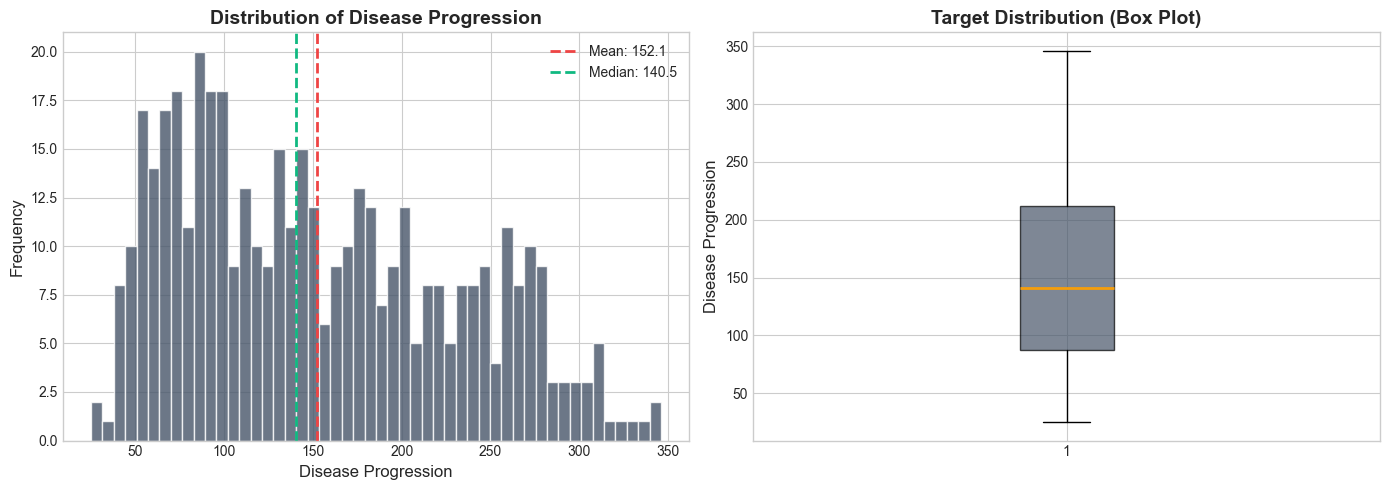


Target Variable Statistics:
  Mean:   152.1
  Median: 140.5
  Std:    77.1
  Min:    25.0
  Max:    346.0


In [8]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df["target"], bins=50, color="#475569", edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Disease Progression", fontsize=12)
axes[0].set_ylabel("Frequency", fontsize=12)
axes[0].set_title("Distribution of Disease Progression", fontsize=14, fontweight="bold")
axes[0].axvline(
    df["target"].mean(),
    color="#ef4444",
    linestyle="--",
    linewidth=2,
    label=f"Mean: {df['target'].mean():.1f}",
)
axes[0].axvline(
    df["target"].median(),
    color="#10b981",
    linestyle="--",
    linewidth=2,
    label=f"Median: {df['target'].median():.1f}",
)
axes[0].legend()

# Box plot
axes[1].boxplot(
    df["target"],
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor="#475569", alpha=0.7),
    medianprops=dict(color="#f59e0b", linewidth=2),
)
axes[1].set_ylabel("Disease Progression", fontsize=12)
axes[1].set_title("Target Distribution (Box Plot)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

print("\nTarget Variable Statistics:")
print(f"  Mean:   {df['target'].mean():.1f}")
print(f"  Median: {df['target'].median():.1f}")
print(f"  Std:    {df['target'].std():.1f}")
print(f"  Min:    {df['target'].min():.1f}")
print(f"  Max:    {df['target'].max():.1f}")

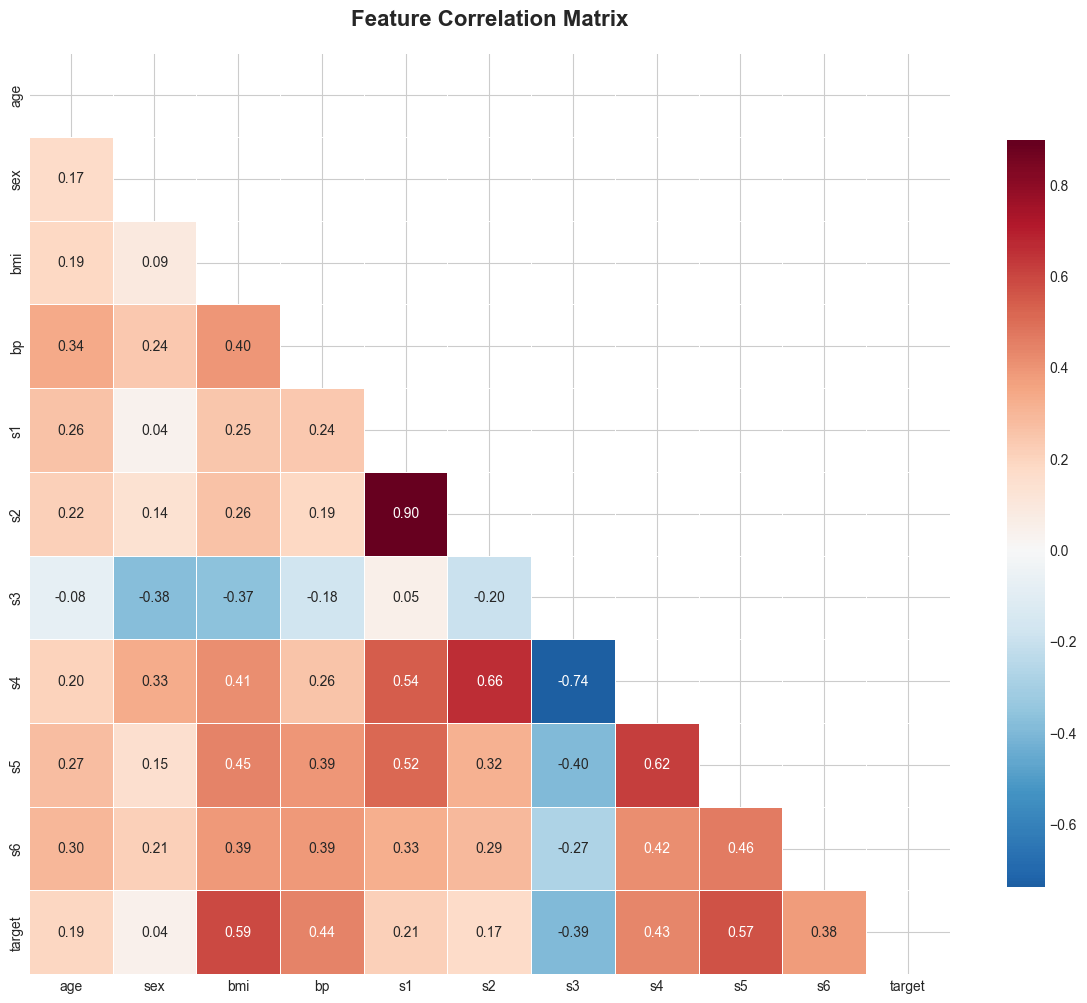


Correlation with Disease Progression (target):
---------------------------------------------
  bmi   : +0.586 +++
  s5    : +0.566 +++
  bp    : +0.441 ++
  s4    : +0.430 ++
  s6    : +0.382 ++
  s1    : +0.212 +
  age   : +0.188 +
  s2    : +0.174 +
  sex   : +0.043 +
  s3    : -0.395 --


In [9]:
# Correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))

correlation_matrix = df.corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
)

plt.title("Feature Correlation Matrix", fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()

# Print correlations with target
print("\nCorrelation with Disease Progression (target):")
print("-" * 45)
target_corr = (
    correlation_matrix["target"].drop("target").sort_values(ascending=False)
)
for feature, corr in target_corr.items():
    indicator = (
        "+++"
        if corr > 0.5
        else "++"
        if corr > 0.3
        else "+"
        if corr > 0
        else "-"
        if corr > -0.3
        else "--"
        if corr > -0.5
        else "---"
    )
    print(f"  {feature:6}: {corr:+.3f} {indicator}")

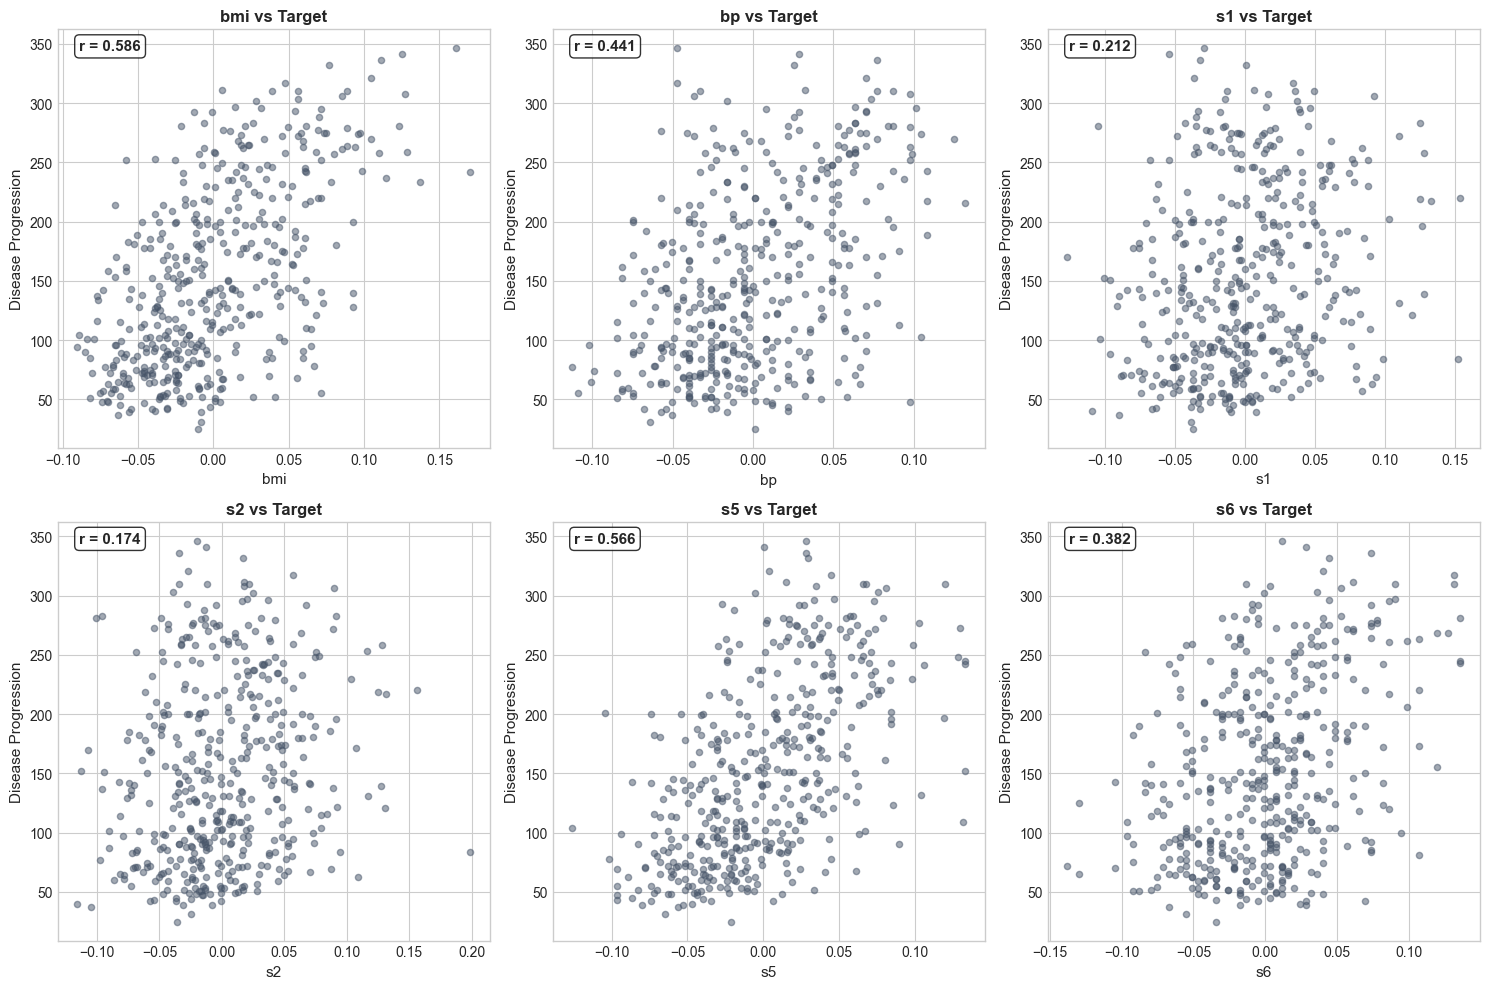

In [10]:
# Scatter plots of key features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

features_to_plot = ["bmi", "bp", "s1", "s2", "s5", "s6"]

for i, feature in enumerate(features_to_plot):
    axes[i].scatter(df[feature], df["target"], alpha=0.5, s=20, c="#475569")
    axes[i].set_xlabel(feature, fontsize=11)
    axes[i].set_ylabel("Disease Progression", fontsize=11)
    axes[i].set_title(f"{feature} vs Target", fontsize=12, fontweight="bold")

    # Add correlation annotation
    corr = df[feature].corr(df["target"])
    axes[i].annotate(
        f"r = {corr:.3f}",
        xy=(0.05, 0.95),
        xycoords="axes fraction",
        fontsize=11,
        fontweight="bold",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )

plt.tight_layout()
plt.show()

## 4. Data Preprocessing

We'll prepare the data for modeling by:
1. Separating features (X) and target (y)
2. Splitting into training and test sets
3. Scaling the features (optional but often beneficial)

In [11]:
# Separate features and target
X = df.drop("target", axis=1)
y = df["target"]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(
    f"\nTraining set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)"
)
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Features shape: (442, 10)
Target shape: (442,)

Training set: 353 samples (80%)
Test set: 89 samples (20%)


In [12]:
# Scale features (important for interpretation and some algorithms)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for better readability
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Feature Scaling Applied (StandardScaler):")
print("  - Mean of each feature: 0")
print("  - Standard deviation of each feature: 1")
print("\nScaled Training Features (first 3 rows):")
X_train_scaled_df.head(3).round(3)

Feature Scaling Applied (StandardScaler):
  - Mean of each feature: 0
  - Standard deviation of each feature: 1

Scaled Training Features (first 3 rows):


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,1.498,1.061,0.220,1.139,0.728,1.056,-0.824,0.711,0.547,-0.061
1,-0.229,1.061,-0.419,-0.711,-0.425,0.272,-1.530,1.484,-0.020,0.367
2,0.085,-0.942,1.019,1.992,-0.310,-0.327,-0.119,-0.062,0.331,-0.319


## 5. Model Training

Now we'll train our Linear Regression model. Linear regression finds the best-fitting line through the data by minimizing the sum of squared residuals.

In [ ]:
# Create and train the model
model = LinearRegression()

# Train on scaled features
model.fit(X_train_scaled, y_train)

print("Model Training Complete!")
print("=" * 50)
print(f"\nModel Intercept (bias term): {model.intercept_:.4f}")
print("  This is the predicted disease progression when all features are at their mean.")

Model Training Complete!

Model Intercept (bias term): 153.7365
  This is the predicted house value when all features are at their mean.
  In dollars: $15,373,654


Model Coefficients (Feature Importance):
--------------------------------------------------

Interpretation: For each 1 standard deviation increase in
the feature, the disease progression changes by this amount

  s1    : -44.45
  s5    : +35.16
  bmi   : +25.61
  s2    : +24.64
  bp    : +16.83
  s4    : +13.14
  sex   : -11.51
  s3    : +7.68
  s6    : +2.35
  age   : +1.75


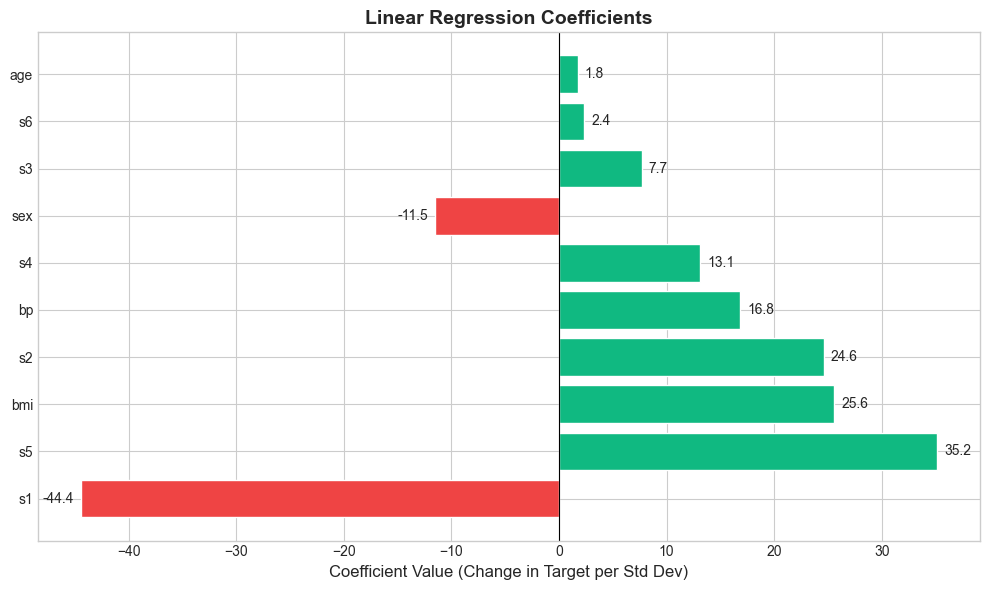

In [14]:
# Display coefficients
coefficients = pd.DataFrame(
    {
        "Feature": X_train.columns,
        "Coefficient": model.coef_,
        "Abs_Coefficient": np.abs(model.coef_),
    }
).sort_values("Abs_Coefficient", ascending=False)

print("Model Coefficients (Feature Importance):")
print("-" * 50)
print("\nInterpretation: For each 1 standard deviation increase in")
print("the feature, the disease progression changes by this amount")
print()

for _, row in coefficients.iterrows():
    direction = "+" if row["Coefficient"] > 0 else "-"
    print(f"  {row['Feature']:6}: {row['Coefficient']:+.2f}")

# Visualize coefficients
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["#10b981" if c > 0 else "#ef4444" for c in coefficients["Coefficient"]]
bars = ax.barh(
    coefficients["Feature"],
    coefficients["Coefficient"],
    color=colors,
    edgecolor="white",
)

ax.set_xlabel("Coefficient Value (Change in Target per Std Dev)", fontsize=12)
ax.set_title("Linear Regression Coefficients", fontsize=14, fontweight="bold")
ax.axvline(0, color="black", linewidth=0.8)

# Add value labels
for bar, val in zip(bars, coefficients["Coefficient"], strict=False):
    ax.annotate(
        f"{val:.1f}",
        xy=(val, bar.get_y() + bar.get_height() / 2),
        xytext=(5 if val > 0 else -5, 0),
        textcoords="offset points",
        ha="left" if val > 0 else "right",
        va="center",
        fontsize=10,
    )

plt.tight_layout()
plt.show()

## 6. Model Evaluation

We'll evaluate our model using several metrics:
- **R-squared (R²)**: Proportion of variance explained (0 to 1, higher is better)
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual values
- **Root Mean Squared Error (RMSE)**: Square root of MSE (in same units as target)
- **Mean Absolute Error (MAE)**: Average absolute difference between predicted and actual values

In [15]:
# Make predictions
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Calculate metrics for both sets
metrics = {
    "Metric": [
        "R-squared (R²)",
        "Mean Squared Error (MSE)",
        "Root Mean Squared Error (RMSE)",
        "Mean Absolute Error (MAE)",
    ],
    "Training Set": [
        r2_score(y_train, y_train_pred),
        mean_squared_error(y_train, y_train_pred),
        np.sqrt(mean_squared_error(y_train, y_train_pred)),
        mean_absolute_error(y_train, y_train_pred),
    ],
    "Test Set": [
        r2_score(y_test, y_test_pred),
        mean_squared_error(y_test, y_test_pred),
        np.sqrt(mean_squared_error(y_test, y_test_pred)),
        mean_absolute_error(y_test, y_test_pred),
    ],
}

metrics_df = pd.DataFrame(metrics)
print("Model Performance Metrics:")
print("=" * 60)
metrics_df

Model Performance Metrics:


,Metric,Training Set,Test Set
0,R-squared (R²),0.527919,0.452603
1,Mean Squared Error (MSE),2868.549703,2900.193628
2,Root Mean Squared Error (RMSE),53.558843,53.853446
3,Mean Absolute Error (MAE),43.483504,42.794095


In [16]:
# Visual interpretation of metrics
print("\nInterpretation of Results:")
print("-" * 60)

r2_test = r2_score(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
mae_test = mean_absolute_error(y_test, y_test_pred)

print(f"\n1. R-squared: {r2_test:.4f}")
print(f"   Our model explains {r2_test*100:.1f}% of the variance in disease progression.")
if r2_test > 0.7:
    print("   This is a good fit for real-world data!")
elif r2_test > 0.5:
    print("   This is a moderate fit - there may be non-linear patterns.")
else:
    print("   Consider adding more features or using non-linear models.")

print(f"\n2. RMSE: {rmse_test:.2f}")
print(f"   On average, our predictions are off by about {rmse_test:.1f} units")

print(f"\n3. MAE: {mae_test:.2f}")
print(f"   The typical error in our predictions is {mae_test:.1f} units")


Interpretation of Results:
------------------------------------------------------------

1. R-squared: 0.4526
   Our model explains 45.3% of the variance in disease progression.
   Consider adding more features or using non-linear models.

2. RMSE: 53.85
   On average, our predictions are off by about 53.9 units

3. MAE: 42.79
   The typical error in our predictions is 42.8 units


## 7. Visualization of Results

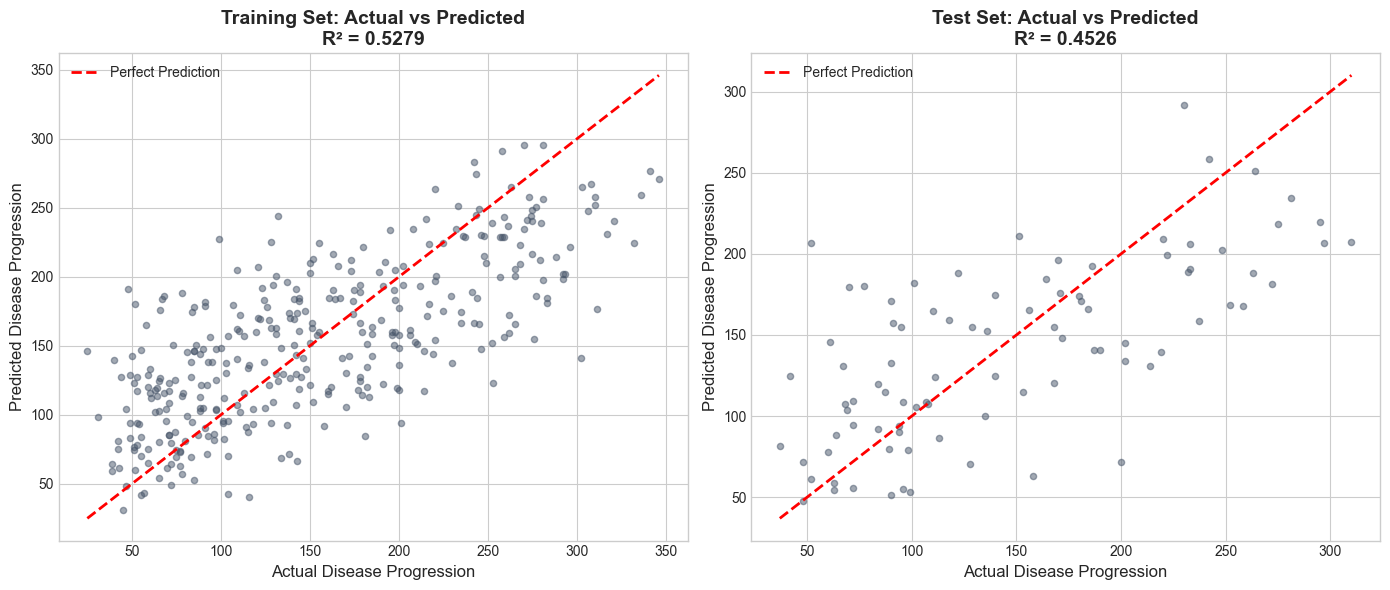

In [17]:
# Actual vs Predicted plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Training set
axes[0].scatter(y_train, y_train_pred, alpha=0.5, s=20, c="#475569")
axes[0].plot(
    [y_train.min(), y_train.max()],
    [y_train.min(), y_train.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
axes[0].set_xlabel("Actual Disease Progression", fontsize=12)
axes[0].set_ylabel("Predicted Disease Progression", fontsize=12)
axes[0].set_title(
    f"Training Set: Actual vs Predicted\nR² = {r2_score(y_train, y_train_pred):.4f}",
    fontsize=14,
    fontweight="bold",
)
axes[0].legend()

# Test set
axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20, c="#475569")
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    "r--",
    lw=2,
    label="Perfect Prediction",
)
axes[1].set_xlabel("Actual Disease Progression", fontsize=12)
axes[1].set_ylabel("Predicted Disease Progression", fontsize=12)
axes[1].set_title(
    f"Test Set: Actual vs Predicted\nR² = {r2_score(y_test, y_test_pred):.4f}",
    fontsize=14,
    fontweight="bold",
)
axes[1].legend()

plt.tight_layout()
plt.show()

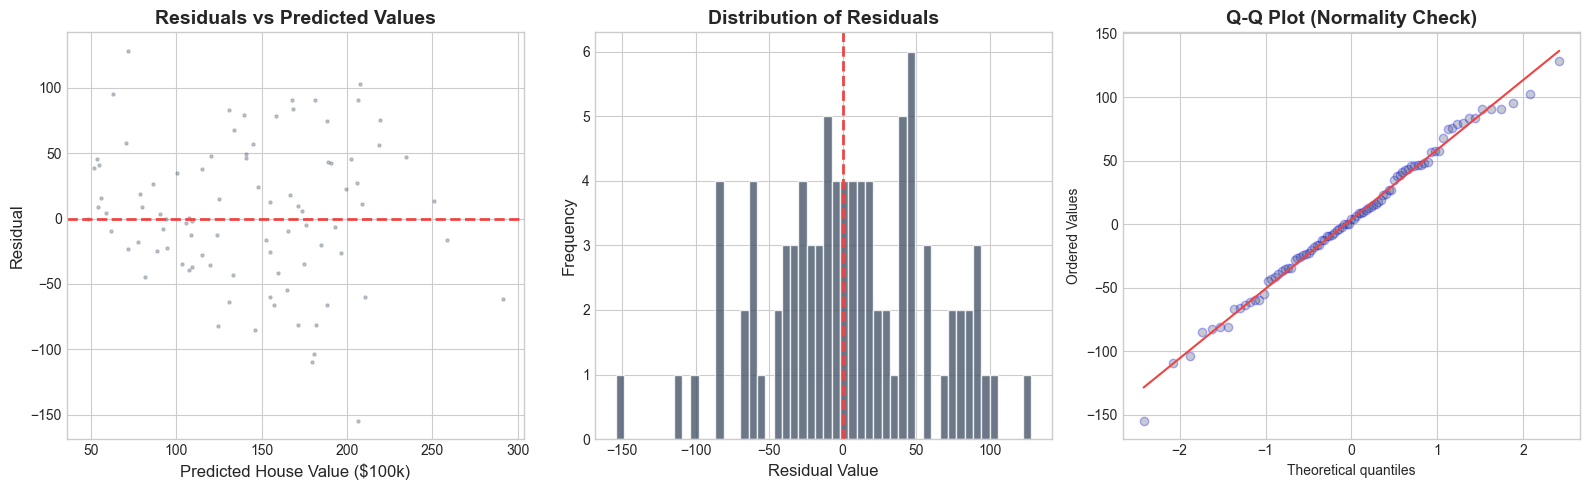

Residuals Statistics:
  Mean: 3.9128 (should be close to 0)
  Std:  54.0154
  Min:  -154.4934
  Max:  128.3333


In [ ]:
# Residuals analysis
residuals_test = y_test - y_test_pred

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Residuals vs Predicted
axes[0].scatter(y_test_pred, residuals_test, alpha=0.5, s=20, c="#475569")
axes[0].axhline(y=0, color="#ef4444", linestyle="--", linewidth=2)
axes[0].set_xlabel("Predicted Disease Progression", fontsize=12)
axes[0].set_ylabel("Residual", fontsize=12)
axes[0].set_title("Residuals vs Predicted Values", fontsize=14, fontweight="bold")

# Residuals histogram
axes[1].hist(residuals_test, bins=30, color="#475569", edgecolor="white", alpha=0.8)
axes[1].axvline(x=0, color="#ef4444", linestyle="--", linewidth=2)
axes[1].set_xlabel("Residual Value", fontsize=12)
axes[1].set_ylabel("Frequency", fontsize=12)
axes[1].set_title("Distribution of Residuals", fontsize=14, fontweight="bold")

# Q-Q plot
from scipy import stats

stats.probplot(residuals_test, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot (Normality Check)", fontsize=14, fontweight="bold")
axes[2].get_lines()[0].set_markerfacecolor("#475569")
axes[2].get_lines()[0].set_alpha(0.5)
axes[2].get_lines()[1].set_color("#ef4444")

plt.tight_layout()
plt.show()

print("Residuals Statistics:")
print(f"  Mean: {residuals_test.mean():.4f} (should be close to 0)")
print(f"  Std:  {residuals_test.std():.4f}")
print(f"  Min:  {residuals_test.min():.4f}")
print(f"  Max:  {residuals_test.max():.4f}")

## 8. Making Predictions

Let's use our trained model to make predictions for new data.

In [19]:
# Example: Predict disease progression for hypothetical patients
# Note: Features are already standardized in the original dataset
example_patients = pd.DataFrame(
    {
        "age": [0.05, -0.04, 0.08],  # Standardized values
        "sex": [0.05, -0.04, 0.05],
        "bmi": [0.06, -0.03, 0.10],  # Higher BMI
        "bp": [0.02, -0.01, 0.05],   # Blood pressure
        "s1": [0.01, -0.02, 0.03],   # Total cholesterol
        "s2": [0.02, -0.03, 0.04],   # LDL
        "s3": [-0.01, 0.03, -0.02],  # HDL (negative = lower)
        "s4": [0.01, -0.02, 0.03],   # Total/HDL ratio
        "s5": [0.03, -0.02, 0.05],   # Triglycerides
        "s6": [0.02, -0.01, 0.04],   # Blood sugar
    },
    index=["Average Patient", "Healthy Patient", "At-Risk Patient"],
)

# Scale the example data using the same scaler
example_scaled = scaler.transform(example_patients)

# Make predictions
predictions = model.predict(example_scaled)

print("Disease Progression Predictions:")
print("=" * 60)
print()

for i, (name, pred) in enumerate(zip(example_patients.index, predictions, strict=False)):
    print(f"{name}:")
    print(
        f"  Key Features: BMI={example_patients.iloc[i]['bmi']:.2f}, "
        f"BP={example_patients.iloc[i]['bp']:.2f}, "
        f"s5={example_patients.iloc[i]['s5']:.2f}"
    )
    print(f"  Predicted Disease Progression: {pred:.1f}")
    print()

Disease Progression Predictions:

Average Patient:
  Key Features: BMI=0.06, BP=0.02, s5=0.03
  Predicted Disease Progression: 205.9

Healthy Patient:
  Key Features: BMI=-0.03, BP=-0.01, s5=-0.02
  Predicted Disease Progression: 127.0

At-Risk Patient:
  Key Features: BMI=0.10, BP=0.05, s5=0.05
  Predicted Disease Progression: 250.4



## 9. Key Insights and Conclusions

### Summary

Our linear regression model achieved the following results:

1. **Model Performance**: R² indicates how much variance in disease progression our model explains
2. **Prediction Accuracy**: RMSE shows the typical error magnitude in our predictions
3. **Feature Importance**: BMI and blood serum measurements are key predictors

### Key Findings

- **BMI** is one of the strongest predictors of disease progression
- **Blood serum measurements** (s1-s6) contain important predictive information
- **s5 (log of triglycerides)** shows strong correlation with the target

### Limitations

1. Linear regression assumes a linear relationship between features and target
2. The model doesn't capture complex interactions between features
3. The dataset is relatively small (442 samples)

### Next Steps

To improve predictions, consider:
- Polynomial features for non-linear relationships
- Regularization (Ridge/Lasso) to prevent overfitting
- More advanced models (Random Forest, Gradient Boosting)

In [20]:
# Final summary
print("\n" + "=" * 60)
print("          LINEAR REGRESSION MODEL SUMMARY")
print("=" * 60)
print("\n  Dataset: Diabetes")
print(f"  Samples: {len(df):,}")
print(f"  Features: {X.shape[1]}")
print(f"\n  Test R²: {r2_test:.4f}")
print(f"  Test RMSE: {rmse_test:.2f}")
print(f"  Test MAE: {mae_test:.2f}")
print("\n  Top 3 Most Important Features:")
for i, (_, row) in enumerate(coefficients.head(3).iterrows()):
    print(f"    {i+1}. {row['Feature']}: {row['Coefficient']:+.2f}")
print("\n" + "=" * 60)


          LINEAR REGRESSION MODEL SUMMARY

  Dataset: Diabetes
  Samples: 442
  Features: 10

  Test R²: 0.4526
  Test RMSE: 53.85
  Test MAE: 42.79

  Top 3 Most Important Features:
    1. s1: -44.45
    2. s5: +35.16
    3. bmi: +25.61

